# Pricing Recommendations — Used Car Dynamic Pricing

Turn ensemble model predictions into actionable **pricing recommendations** for sellers, buyers, and marketplace platforms.

**Input:** `outputs/ensemble_validation_predictions.csv`  
**Output:** `outputs/pricing_recommendations.csv`

We use the weighted ensemble prediction as the **fair price** estimate and compare it to the current **listing price**.

## What Is Fair Price?

**Fair price** (`fair_price_prediction`) is the model's estimate of a vehicle's market value given its features. It reflects what similar cars are expected to transact for, based on patterns learned from historical listings.

**Listing price** (`listing_price`) is the price currently shown on the platform. When listing price is far above fair price, the car may be **overpriced** and slow to sell. When it is far below fair price, it may be **underpriced** and attract quick interest but leave money on the table.

## Why a 10% Threshold?

A **±10%** band around fair price defines "Fair Price" status:

- **> +10%** → Overpriced (listing materially above market)
- **< -10%** → Underpriced (listing materially below market)
- **Otherwise** → Fair Price (within normal market noise)

Ten percent is a practical rule of thumb in used-car retail: small deviations are common due to condition, negotiation, and local demand; larger gaps usually signal a repricing opportunity.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

INPUT_PATH = PROJECT_ROOT / "outputs" / "ensemble_validation_predictions.csv"
OUTPUT_PATH = PROJECT_ROOT / "outputs" / "pricing_recommendations.csv"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

THRESHOLD_PCT = 0.10
OVERPRICED_ADJ = 1.03
UNDERPRICED_ADJ = 0.97

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["savefig.dpi"] = 150

## 1. Load Ensemble Validation Predictions

In [2]:
raw = pd.read_csv(INPUT_PATH)
print(f"Rows: {len(raw):,}")
raw.head()

Rows: 30,000


,SaleID,actual_price,pred_xgb,pred_catboost,pred_lightgbm,pred_equal,pred_weighted,residual_equal,residual_weighted,abs_error_equal,abs_error_weighted
0,59770,999,1019.209,1008.471860,1146.979695,1058.220185,1052.171638,-59.220185,-53.171638,59.220185,53.171638
1,21362,8500,8292.025,8376.696000,8593.976258,8420.899086,8424.945877,79.100914,75.054123,79.100914,75.054123
2,127324,15500,15845.819,15779.062021,17310.804880,16311.895300,16251.936275,-811.895300,-751.936275,811.895300,751.936275
3,140509,10000,9978.174,9967.346154,10076.665580,10007.395245,10002.307551,-7.395245,-2.307551,7.395245,2.307551
4,144297,2999,2963.989,2941.443181,2851.907580,2919.113253,2919.091664,79.886747,79.908336,79.886747,79.908336


## 2. Rename Core Price Columns

In [3]:
df = raw.rename(
    columns={
        "actual_price": "listing_price",
        "pred_weighted": "fair_price_prediction",
    }
)[["SaleID", "listing_price", "fair_price_prediction"]].copy()

df.head()

,SaleID,listing_price,fair_price_prediction
0,59770,999,1052.171638
1,21362,8500,8424.945877
2,127324,15500,16251.936275
3,140509,10000,10002.307551
4,144297,2999,2919.091664


## 3–4. Pricing Metrics and Status

In [4]:
df["price_gap"] = df["listing_price"] - df["fair_price_prediction"]
df["price_gap_pct"] = df["price_gap"] / df["fair_price_prediction"]

def assign_status(gap_pct: float) -> str:
    if gap_pct > THRESHOLD_PCT:
        return "Overpriced"
    if gap_pct < -THRESHOLD_PCT:
        return "Underpriced"
    return "Fair Price"

df["pricing_status"] = df["price_gap_pct"].apply(assign_status)
df["pricing_status"].value_counts()

pricing_status
Fair Price     20804
Underpriced     4810
Overpriced      4386
Name: count, dtype: int64

## 5–6. Recommended Price and Discount

In [5]:
def recommended_price(row: pd.Series) -> float:
    fair = row["fair_price_prediction"]
    listing = row["listing_price"]
    status = row["pricing_status"]
    if status == "Overpriced":
        return fair * OVERPRICED_ADJ
    if status == "Underpriced":
        return fair * UNDERPRICED_ADJ
    return listing

df["recommended_price"] = df.apply(recommended_price, axis=1)
df["recommended_discount"] = df["listing_price"] - df["recommended_price"]

df.head(10)

,SaleID,listing_price,fair_price_prediction,price_gap,price_gap_pct,pricing_status,recommended_price,recommended_discount
0,59770,999,1052.171638,-53.171638,-0.050535,Fair Price,999.0,0.0
1,21362,8500,8424.945877,75.054123,0.008909,Fair Price,8500.0,0.0
2,127324,15500,16251.936275,-751.936275,-0.046267,Fair Price,15500.0,0.0
3,140509,10000,10002.307551,-2.307551,-0.000231,Fair Price,10000.0,0.0
4,144297,2999,2919.091664,79.908336,0.027374,Fair Price,2999.0,0.0
5,96370,58000,53241.254310,4758.745690,0.089381,Fair Price,58000.0,0.0
6,49742,1600,1689.307260,-89.307260,-0.052866,Fair Price,1600.0,0.0
7,47389,1600,1609.184575,-9.184575,-0.005708,Fair Price,1600.0,0.0
8,58378,2500,2538.020713,-38.020713,-0.014980,Fair Price,2500.0,0.0
9,69047,800,786.459943,13.540057,0.017216,Fair Price,800.0,0.0


### Recommendation Logic

| Status | Recommended price |
|--------|-------------------|
| Overpriced | `fair_price × 1.03` — nudge toward market while leaving small buffer |
| Underpriced | `fair_price × 0.97` — suggest raising price without overshooting |
| Fair Price | keep `listing_price` — no change suggested |

## 7. Business Summary

In [6]:
status_counts = df["pricing_status"].value_counts()

summary = {
    "total_vehicles": len(df),
    "overpriced_count": int(status_counts.get("Overpriced", 0)),
    "underpriced_count": int(status_counts.get("Underpriced", 0)),
    "fair_priced_count": int(status_counts.get("Fair Price", 0)),
    "avg_price_gap": df["price_gap"].mean(),
    "avg_price_gap_pct": df["price_gap_pct"].mean(),
}

summary_df = pd.DataFrame([summary])
print("Business Summary")
print("=" * 50)
for k, v in summary.items():
    if "pct" in k:
        print(f"{k}: {v:.2%}")
    elif "gap" in k and "pct" not in k:
        print(f"{k}: {v:,.2f}")
    else:
        print(f"{k}: {v:,}" if isinstance(v, (int, np.integer)) else f"{k}: {v}")
summary_df

Business Summary
total_vehicles: 30,000
overpriced_count: 4,386
underpriced_count: 4,810
fair_priced_count: 20,804
avg_price_gap: 22.89
avg_price_gap_pct: 0.51%


,total_vehicles,overpriced_count,underpriced_count,fair_priced_count,avg_price_gap,avg_price_gap_pct
0,30000,4386,4810,20804,22.894842,0.005071


## 8. Charts

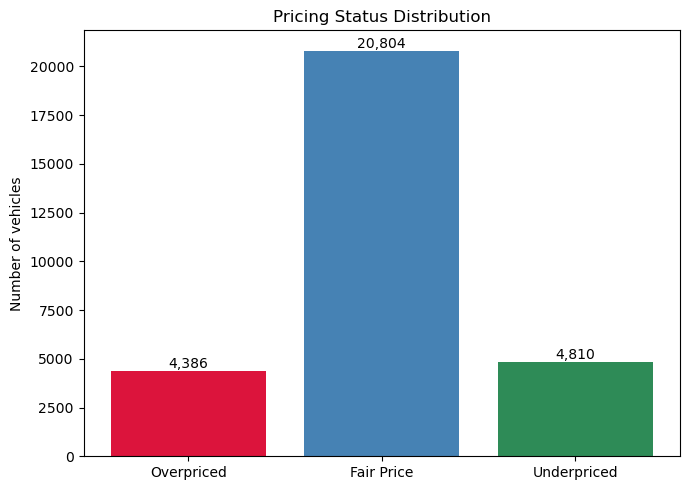

In [7]:
# 8a. pricing_status distribution
fig, ax = plt.subplots(figsize=(7, 5))
order = ["Overpriced", "Fair Price", "Underpriced"]
counts = df["pricing_status"].value_counts().reindex(order)
colors = {"Overpriced": "crimson", "Fair Price": "steelblue", "Underpriced": "seagreen"}
ax.bar(counts.index, counts.values, color=[colors[s] for s in counts.index])
ax.set_title("Pricing Status Distribution")
ax.set_ylabel("Number of vehicles")
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
fig.savefig(FIG_DIR / "pricing_status_distribution.png", bbox_inches="tight")
plt.show()

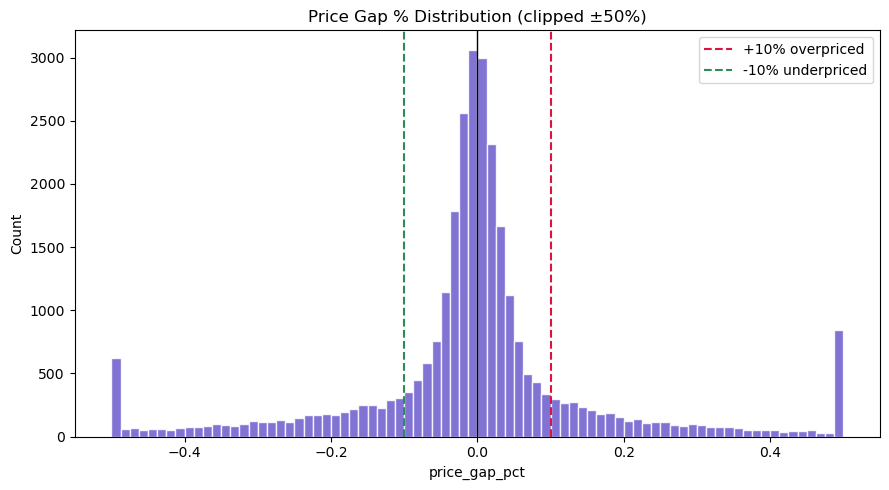

In [8]:
# 8b. price_gap_pct distribution
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df["price_gap_pct"].clip(-0.5, 0.5), bins=80, color="slateblue", edgecolor="white", alpha=0.85)
ax.axvline(THRESHOLD_PCT, color="crimson", linestyle="--", label="+10% overpriced")
ax.axvline(-THRESHOLD_PCT, color="seagreen", linestyle="--", label="-10% underpriced")
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Price Gap % Distribution (clipped ±50%)")
ax.set_xlabel("price_gap_pct")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / "price_gap_pct_distribution.png", bbox_inches="tight")
plt.show()

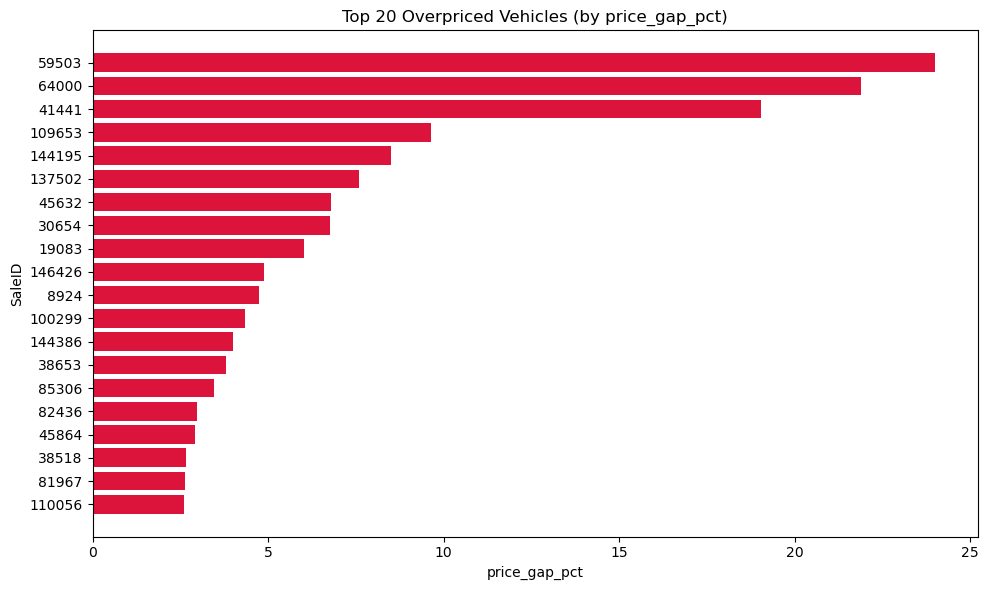

,SaleID,listing_price,fair_price_prediction,price_gap,price_gap_pct,pricing_status,recommended_price,recommended_discount
15269,59503,65,2.599227,62.400773,24.007434,Overpriced,2.677204,62.322796
17546,64000,13000,567.772227,12432.227773,21.896506,Overpriced,584.805394,12415.194606
8290,41441,100,4.988152,95.011848,19.047505,Overpriced,5.137796,94.862204
2068,109653,27500,2583.915233,24916.084767,9.642764,Overpriced,2661.432690,24838.567310
16760,144195,12968,1364.964889,11603.035111,8.500611,Overpriced,1405.913835,11562.086165
4247,137502,11490,1338.318646,10151.681354,7.585399,Overpriced,1378.468205,10111.531795
26968,45632,50,6.405872,43.594128,6.805339,Overpriced,6.598048,43.401952
18741,30654,850,109.428144,740.571856,6.767654,Overpriced,112.710988,737.289012
27199,19083,33500,4760.774545,28739.225455,6.036670,Overpriced,4903.597781,28596.402219
25464,146426,1900,322.467718,1577.532282,4.892063,Overpriced,332.141749,1567.858251


In [9]:
# 8c. top 20 overpriced
top_over = df[df["pricing_status"] == "Overpriced"].nlargest(20, "price_gap_pct")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_over["SaleID"].astype(str), top_over["price_gap_pct"], color="crimson")
ax.set_title("Top 20 Overpriced Vehicles (by price_gap_pct)")
ax.set_xlabel("price_gap_pct")
ax.set_ylabel("SaleID")
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(FIG_DIR / "top20_overpriced.png", bbox_inches="tight")
plt.show()
top_over

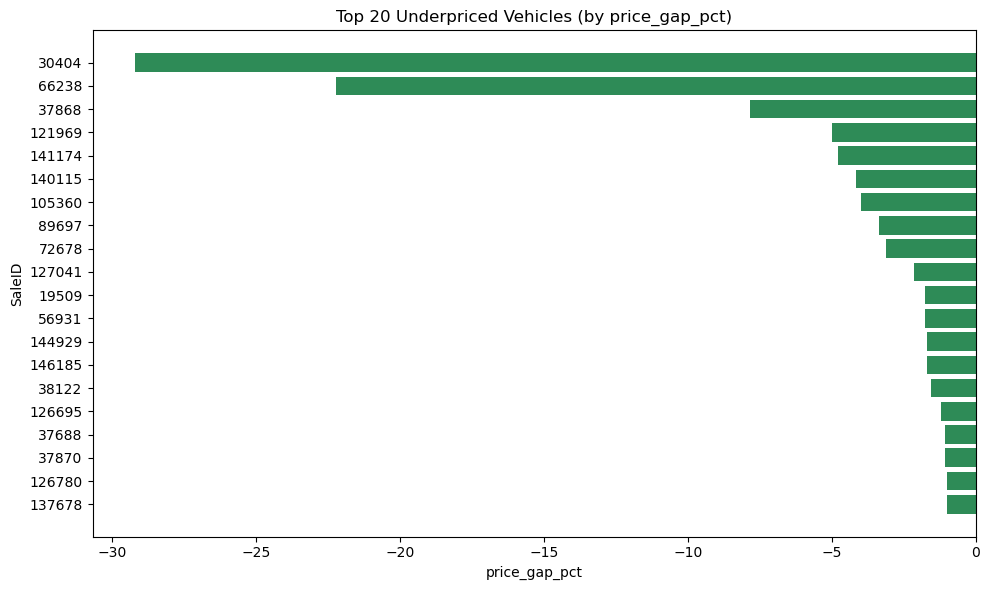

,SaleID,listing_price,fair_price_prediction,price_gap,price_gap_pct,pricing_status,recommended_price,recommended_discount
26416,30404,70,-2.479757,72.479757,-29.228569,Underpriced,-2.405365,72.405365
20205,66238,340,-16.014381,356.014381,-22.230918,Underpriced,-15.533949,355.533949
5373,37868,190,-27.825823,217.825823,-7.828190,Underpriced,-26.991048,216.991048
16394,121969,249,-62.617078,311.617078,-4.976551,Underpriced,-60.738566,309.738566
5983,141174,99,-26.106812,125.106812,-4.792114,Underpriced,-25.323607,124.323607
12269,140115,285,-90.346682,375.346682,-4.154515,Underpriced,-87.636281,372.636281
10325,105360,320,-107.123306,427.123306,-3.987212,Underpriced,-103.909607,423.909607
6210,89697,225,-95.511911,320.511911,-3.355727,Underpriced,-92.646554,317.646554
2937,72678,45,-21.361231,66.361231,-3.106620,Underpriced,-20.720394,65.720394
179,127041,90,-77.952934,167.952934,-2.154543,Underpriced,-75.614346,165.614346


In [10]:
# 8d. top 20 underpriced
top_under = df[df["pricing_status"] == "Underpriced"].nsmallest(20, "price_gap_pct")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_under["SaleID"].astype(str), top_under["price_gap_pct"], color="seagreen")
ax.set_title("Top 20 Underpriced Vehicles (by price_gap_pct)")
ax.set_xlabel("price_gap_pct")
ax.set_ylabel("SaleID")
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(FIG_DIR / "top20_underpriced.png", bbox_inches="tight")
plt.show()
top_under

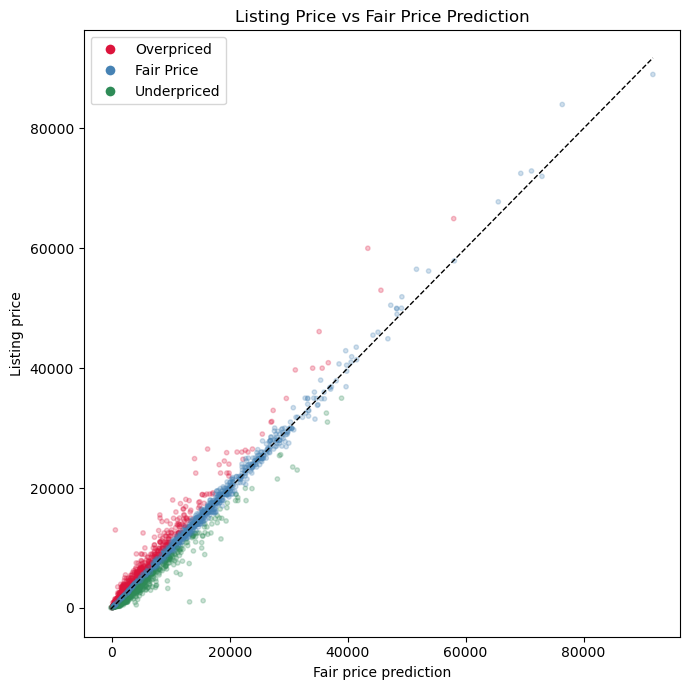

In [11]:
# 8e. listing vs fair scatter
fig, ax = plt.subplots(figsize=(7, 7))
sample = df.sample(min(5000, len(df)), random_state=42)
ax.scatter(
    sample["fair_price_prediction"],
    sample["listing_price"],
    alpha=0.25,
    s=10,
    c=sample["pricing_status"].map({"Overpriced": "crimson", "Fair Price": "steelblue", "Underpriced": "seagreen"}),
)
lo = min(sample["fair_price_prediction"].min(), sample["listing_price"].min())
hi = max(sample["fair_price_prediction"].max(), sample["listing_price"].max())
ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="listing = fair")
ax.set_xlabel("Fair price prediction")
ax.set_ylabel("Listing price")
ax.set_title("Listing Price vs Fair Price Prediction")
ax.legend(handles=[], labels=[])
from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="crimson", label="Overpriced", markersize=8),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue", label="Fair Price", markersize=8),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="seagreen", label="Underpriced", markersize=8),
]
ax.legend(handles=legend_elems)
plt.tight_layout()
fig.savefig(FIG_DIR / "listing_vs_fair_scatter.png", bbox_inches="tight")
plt.show()

## 9. Save Recommendations

In [12]:
export_cols = [
    "SaleID",
    "listing_price",
    "fair_price_prediction",
    "price_gap",
    "price_gap_pct",
    "pricing_status",
    "recommended_price",
    "recommended_discount",
]
df[export_cols].to_csv(OUTPUT_PATH, index=False)
print(f"Saved: {OUTPUT_PATH}")
df[export_cols].head()

Saved: outputs/pricing_recommendations.csv


,SaleID,listing_price,fair_price_prediction,price_gap,price_gap_pct,pricing_status,recommended_price,recommended_discount
0,59770,999,1052.171638,-53.171638,-0.050535,Fair Price,999.0,0.0
1,21362,8500,8424.945877,75.054123,0.008909,Fair Price,8500.0,0.0
2,127324,15500,16251.936275,-751.936275,-0.046267,Fair Price,15500.0,0.0
3,140509,10000,10002.307551,-2.307551,-0.000231,Fair Price,10000.0,0.0
4,144297,2999,2919.091664,79.908336,0.027374,Fair Price,2999.0,0.0


## 10. How Stakeholders Can Use This

### Sellers

- **Overpriced:** Lower toward `recommended_price` to improve time-on-market and inquiry rate.
- **Underpriced:** Consider raising price toward fair value to capture margin without losing competitiveness.
- **Fair Price:** Maintain listing; monitor weekly for market shifts.

### Buyers

- **Overpriced:** Use `fair_price_prediction` as a negotiation anchor; larger `price_gap_pct` implies more room to bargain.
- **Underpriced:** Act quickly — listings far below fair price often sell fast.
- **Fair Price:** Compare against similar vehicles; price is already near model estimate.

### Platforms (marketplaces / dealers)

- Flag overpriced inventory for repricing campaigns and SEO/listing quality scores.
- Promote underpriced deals in recommendation feeds to drive conversion.
- Aggregate `pricing_status` by brand/region for market intelligence and dynamic pricing APIs.
- Use `recommended_discount` to power automated "suggested price drop" alerts.